# Social Media Sentiment Analysis — NLP

## Objective

The objective of this project is to analyze social media text using Natural Language Processing (NLP) techniques and classify the text into Positive, Negative, and Neutral sentiments.

## Dataset

The Sentiment dataset contains social media text and related information used to perform sentiment analysis and identify patterns in user sentiment.

## Technologies Used

* Python
* Pandas
* NumPy
* NLTK
* TextBlob
* Matplotlib
* Seaborn
* WordCloud
* Jupyter Notebook

## Workflow

1. Load and inspect the sentiment dataset
2. Clean and preprocess the text data
3. Remove unwanted characters and irrelevant text
4. Calculate sentiment polarity and subjectivity using TextBlob
5. Classify text into Positive, Negative, and Neutral sentiments
6. Analyze frequently occurring words
7. Generate a word cloud visualization
8. Analyze sentiment across social media platforms
9. Visualize the results
10. Summarize the key findings

## Conclusion

Natural Language Processing techniques were used to analyze social media text and classify posts into Positive, Negative, and Neutral sentiments. The analysis provided insights into overall sentiment, frequently occurring words, and sentiment patterns across different social media platforms.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 3) Sentiment dataset.csv to 3) Sentiment dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("3) Sentiment dataset.csv")

print("First 5 rows:")
display(df.head())

print("Dataset shape:", df.shape)

First 5 rows:


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


Dataset shape: (732, 15)


In [ ]:
import pandas as pd

df = pd.read_csv("3) Sentiment dataset.csv")

print("First 5 rows:")
display(df.head())

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment distribution:")
print(df["Sentiment"].value_counts())

First 5 rows:


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


Dataset shape: (732, 15)

Column names:
['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

Missing values:
Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

Sentiment distribution:
Sentiment
Positive               44
Joy                    42
Excitement             32
Happy                  14
Neutral                14
                       ..
Vibrancy                1
Culinary Adventure      1
Mesmerizing             1
Thrilling Journey       1
Winter Magic            1
Name: count, Length: 279, dtype: int64


In [ ]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    text = re.sub(r'@\w+|#\w+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

df['Clean_Text'] = df['Text'].apply(preprocess_text)

display(df[['Text', 'Clean_Text']].head())

,Text,Clean_Text
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park
1,Traffic was terrible this morning. ...,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight


In [ ]:
!pip install textblob

In [ ]:
from textblob import TextBlob

df['Polarity'] = df['Clean_Text'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

df['Subjectivity'] = df['Clean_Text'].apply(
    lambda x: TextBlob(x).sentiment.subjectivity
)

display(
    df[['Text', 'Clean_Text', 'Polarity', 'Subjectivity']].head(10)
)

,Text,Clean_Text,Polarity,Subjectivity
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park,0.675000,0.800000
1,Traffic was terrible this morning. ...,traffic terrible morning,-1.000000,1.000000
2,Just finished an amazing workout! 💪 ...,finished amazing workout,0.600000,0.900000
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway,0.375000,0.750000
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight,0.136364,0.454545
5,Feeling grateful for the little things in lif...,feeling grateful little things life,-0.187500,0.500000
6,Rainy days call for cozy blankets and hot coc...,rainy days call cozy blankets hot cocoa,0.025000,0.800000
7,The new movie release is a must-watch! ...,new movie release mustwatch,0.136364,0.454545
8,Political discussions heating up on the timel...,political discussions heating timeline,0.000000,0.100000
9,Missing summer vibes and beach days. ...,missing summer vibes beach days,-0.200000,0.050000


In [ ]:
from textblob import TextBlob

df['Polarity'] = df['Clean_Text'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

df['Subjectivity'] = df['Clean_Text'].apply(
    lambda x: TextBlob(x).sentiment.subjectivity
)

display(df[['Text', 'Clean_Text', 'Polarity', 'Subjectivity']].head(10))

,Text,Clean_Text,Polarity,Subjectivity
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park,0.675000,0.800000
1,Traffic was terrible this morning. ...,traffic terrible morning,-1.000000,1.000000
2,Just finished an amazing workout! 💪 ...,finished amazing workout,0.600000,0.900000
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway,0.375000,0.750000
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight,0.136364,0.454545
5,Feeling grateful for the little things in lif...,feeling grateful little things life,-0.187500,0.500000
6,Rainy days call for cozy blankets and hot coc...,rainy days call cozy blankets hot cocoa,0.025000,0.800000
7,The new movie release is a must-watch! ...,new movie release mustwatch,0.136364,0.454545
8,Political discussions heating up on the timel...,political discussions heating timeline,0.000000,0.100000
9,Missing summer vibes and beach days. ...,missing summer vibes beach days,-0.200000,0.050000


In [ ]:
def classify_sentiment(polarity):
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df['Predicted_Sentiment'] = df['Polarity'].apply(classify_sentiment)

display(
    df[['Text', 'Polarity', 'Predicted_Sentiment']].head(10)
)

,Text,Polarity,Predicted_Sentiment
0,Enjoying a beautiful day at the park! ...,0.675000,Positive
1,Traffic was terrible this morning. ...,-1.000000,Negative
2,Just finished an amazing workout! 💪 ...,0.600000,Positive
3,Excited about the upcoming weekend getaway! ...,0.375000,Positive
4,Trying out a new recipe for dinner tonight. ...,0.136364,Positive
5,Feeling grateful for the little things in lif...,-0.187500,Negative
6,Rainy days call for cozy blankets and hot coc...,0.025000,Positive
7,The new movie release is a must-watch! ...,0.136364,Positive
8,Political discussions heating up on the timel...,0.000000,Neutral
9,Missing summer vibes and beach days. ...,-0.200000,Negative


In [ ]:
print("Predicted Sentiment Distribution:")
print(df['Predicted_Sentiment'].value_counts())

Predicted Sentiment Distribution:
Predicted_Sentiment
Neutral     332
Positive    281
Negative    119
Name: count, dtype: int64


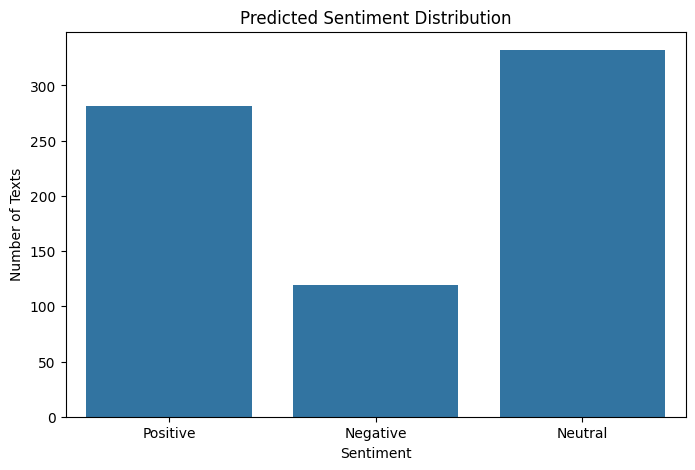

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Predicted_Sentiment'
)

plt.title('Predicted Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Texts')

plt.show()

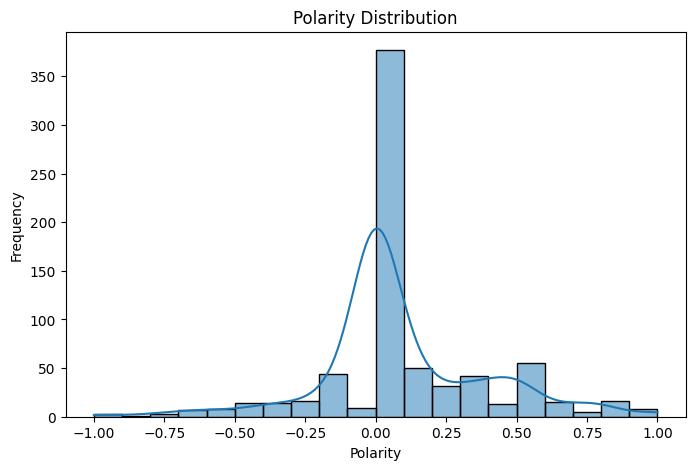

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df['Polarity'],
    bins=20,
    kde=True
)

plt.title('Polarity Distribution')
plt.xlabel('Polarity')
plt.ylabel('Frequency')

plt.show()

In [ ]:
!pip install wordcloud

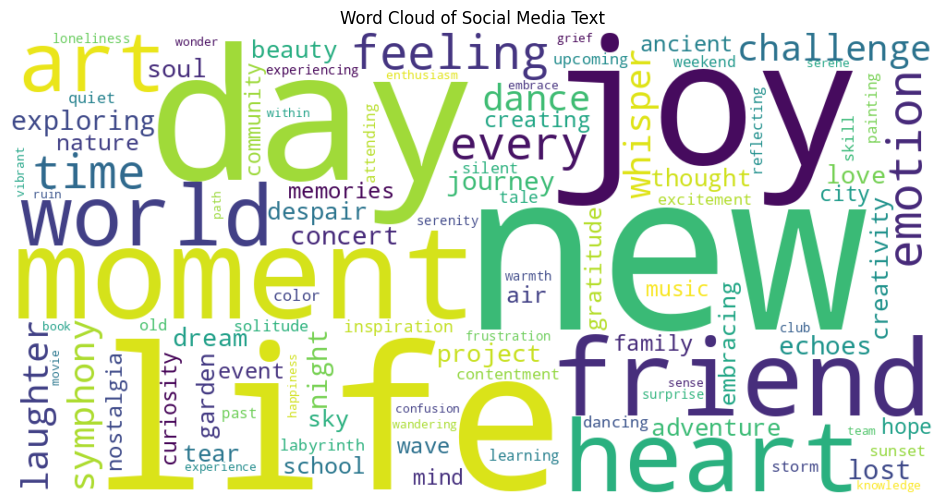

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = ' '.join(df['Clean_Text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Social Media Text')
plt.show()

In [ ]:
from collections import Counter

all_words = ' '.join(df['Clean_Text']).split()

word_counts = Counter(all_words)

most_common_words = word_counts.most_common(20)

print("Top 20 Most Frequent Words:")
for word, count in most_common_words:
    print(f"{word}: {count}")

Top 20 Most Frequent Words:
new: 43
like: 27
day: 26
feeling: 26
dreams: 25
laughter: 24
heart: 24
night: 23
joy: 23
life: 22
world: 21
art: 21
beauty: 20
journey: 20
every: 19
sky: 19
symphony: 18
dance: 18
exploring: 17
friends: 17


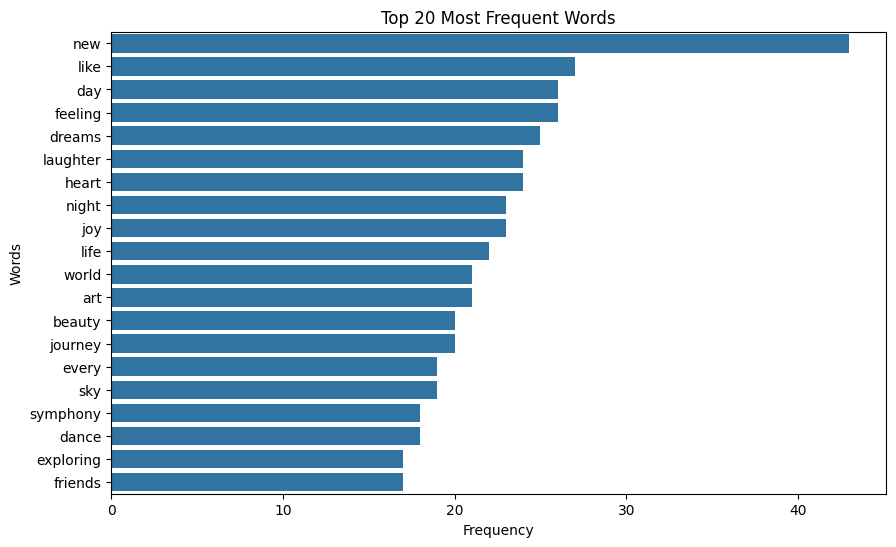

In [ ]:
words = [word for word, count in most_common_words]
counts = [count for word, count in most_common_words]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=counts,
    y=words
)

plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.ylabel('Words')

plt.show()

In [ ]:
from collections import Counter

def get_top_words(sentiment, n=10):
    texts = df[df['Predicted_Sentiment'] == sentiment]['Clean_Text']

    words = ' '.join(texts).split()

    return Counter(words).most_common(n)

positive_words = get_top_words('Positive')
negative_words = get_top_words('Negative')
neutral_words = get_top_words('Neutral')

print("Top Positive Words:")
print(positive_words)

print("\nTop Negative Words:")
print(negative_words)

print("\nTop Neutral Words:")
print(neutral_words)

Top Positive Words:
[('new', 41), ('joy', 22), ('laughter', 15), ('old', 12), ('day', 11), ('book', 11), ('challenging', 11), ('love', 11), ('heart', 11), ('project', 10)]

Top Negative Words:
[('feeling', 9), ('past', 9), ('like', 9), ('echoes', 9), ('grief', 7), ('shattered', 7), ('warmth', 6), ('day', 6), ('despair', 6), ('dreams', 6)]

Top Neutral Words:
[('beauty', 14), ('night', 14), ('dreams', 14), ('life', 12), ('emotions', 12), ('symphony', 12), ('lifes', 11), ('journey', 11), ('dance', 11), ('soul', 11)]


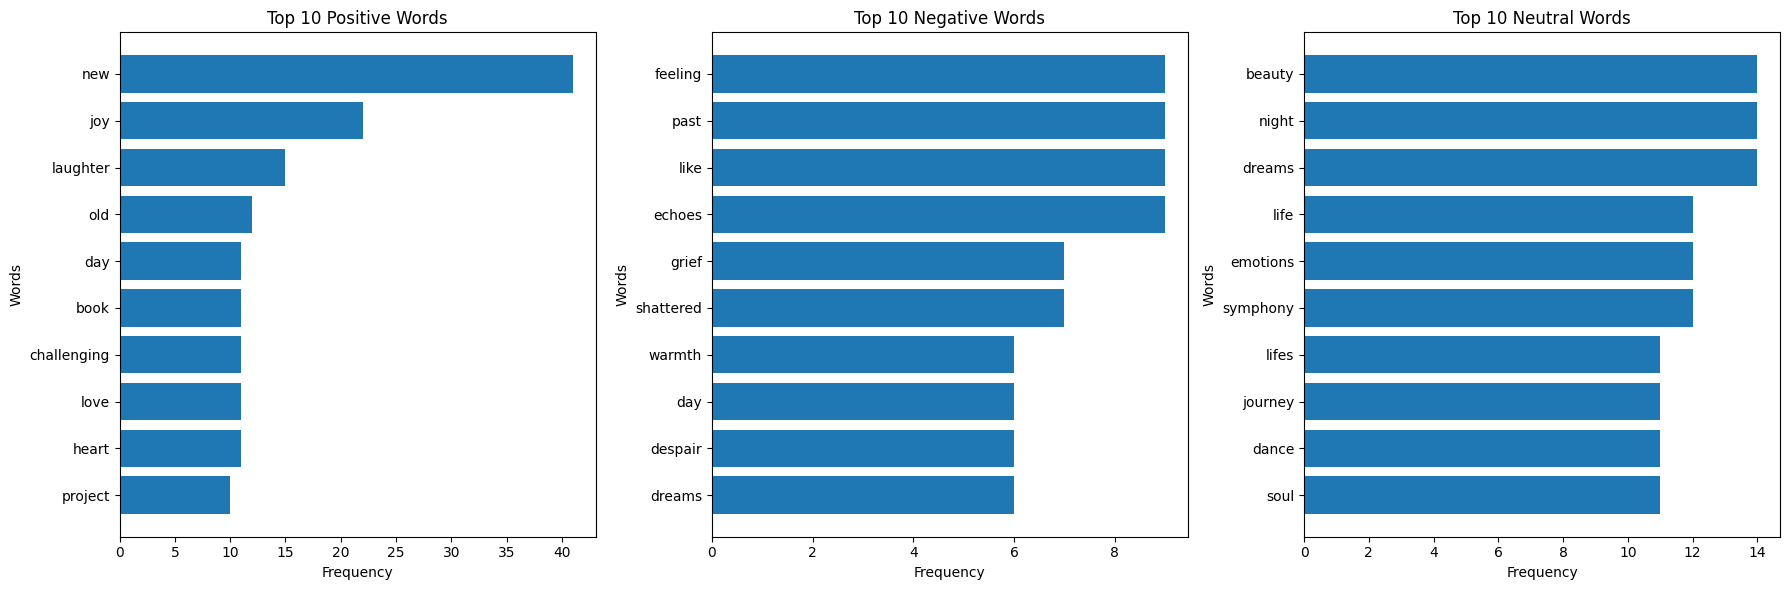

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sentiments = {
    'Positive': positive_words,
    'Negative': negative_words,
    'Neutral': neutral_words
}

for ax, (sentiment, words) in zip(axes, sentiments.items()):
    words_list = [word for word, count in words]
    counts_list = [count for word, count in words]

    ax.barh(words_list[::-1], counts_list[::-1])
    ax.set_title(f'Top 10 {sentiment} Words')
    ax.set_xlabel('Frequency')
    ax.set_ylabel('Words')

plt.tight_layout()
plt.show()

In [ ]:
sentiment_counts = df['Predicted_Sentiment'].value_counts()

sentiment_percentages = (
    df['Predicted_Sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sentiment_summary = pd.DataFrame({
    'Count': sentiment_counts,
    'Percentage': sentiment_percentages
})

print("Overall Sentiment Summary:")
display(sentiment_summary)

Overall Sentiment Summary:


,Count,Percentage
Predicted_Sentiment,,
Neutral,332,45.36
Positive,281,38.39
Negative,119,16.26


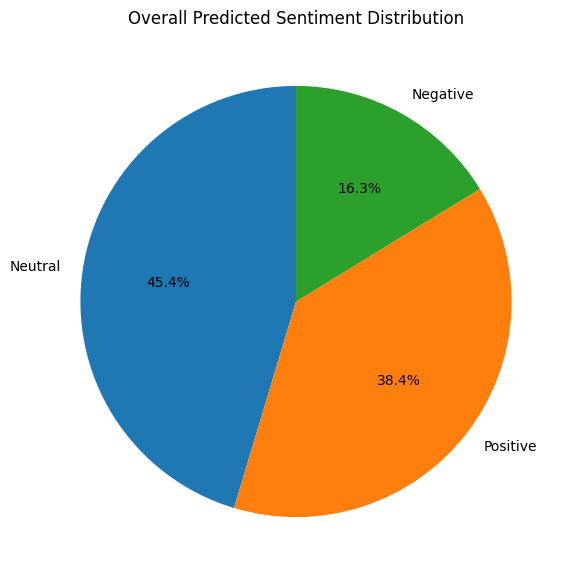

In [ ]:
plt.figure(figsize=(7, 7))

df['Predicted_Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Overall Predicted Sentiment Distribution')
plt.ylabel('')

plt.show()

In [ ]:
platform_sentiment = pd.crosstab(
    df['Platform'],
    df['Predicted_Sentiment']
)

print("Sentiment by Platform:")
display(platform_sentiment)

Sentiment by Platform:


Predicted_Sentiment,Negative,Neutral,Positive
Platform,,,
Facebook,38,115,78
Instagram,34,111,113
Twitter,23,54,51
Twitter,24,52,39


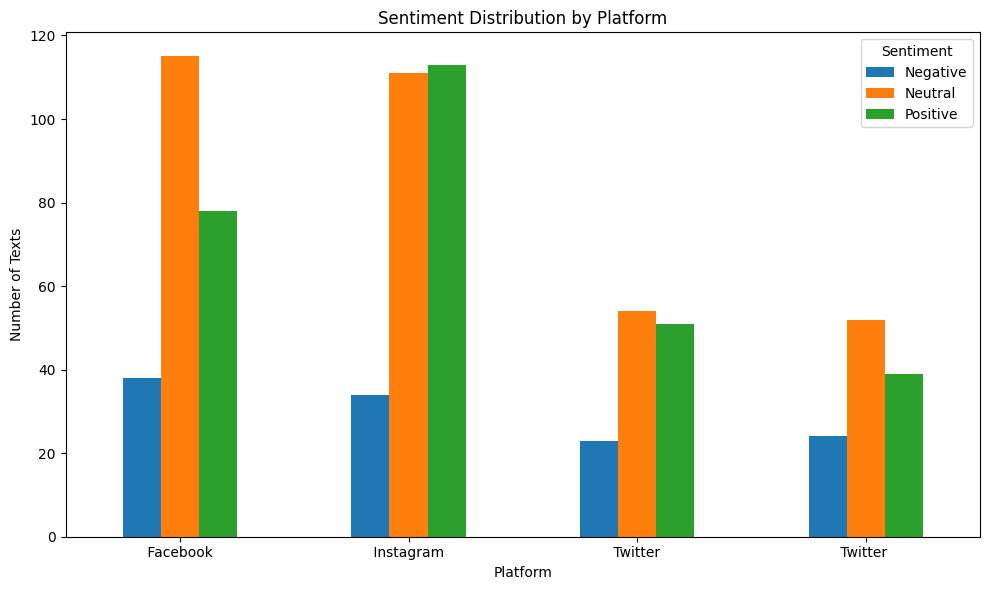

In [ ]:
platform_sentiment.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Sentiment Distribution by Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Texts')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')

plt.tight_layout()
plt.show()

In [ ]:
print("Unique platform names:")
for platform in df['Platform'].unique():
    print(repr(platform))

Unique platform names:
' Twitter  '
' Instagram '
' Facebook '
' Twitter '


In [ ]:
df['Platform'] = df['Platform'].str.strip()

print("Cleaned platform names:")
print(df['Platform'].unique())

Cleaned platform names:
['Twitter' 'Instagram' 'Facebook']


In [ ]:
platform_sentiment = pd.crosstab(
    df['Platform'],
    df['Predicted_Sentiment']
)

print("Corrected Sentiment by Platform:")
display(platform_sentiment)

Corrected Sentiment by Platform:


Predicted_Sentiment,Negative,Neutral,Positive
Platform,,,
Facebook,38,115,78
Instagram,34,111,113
Twitter,47,106,90


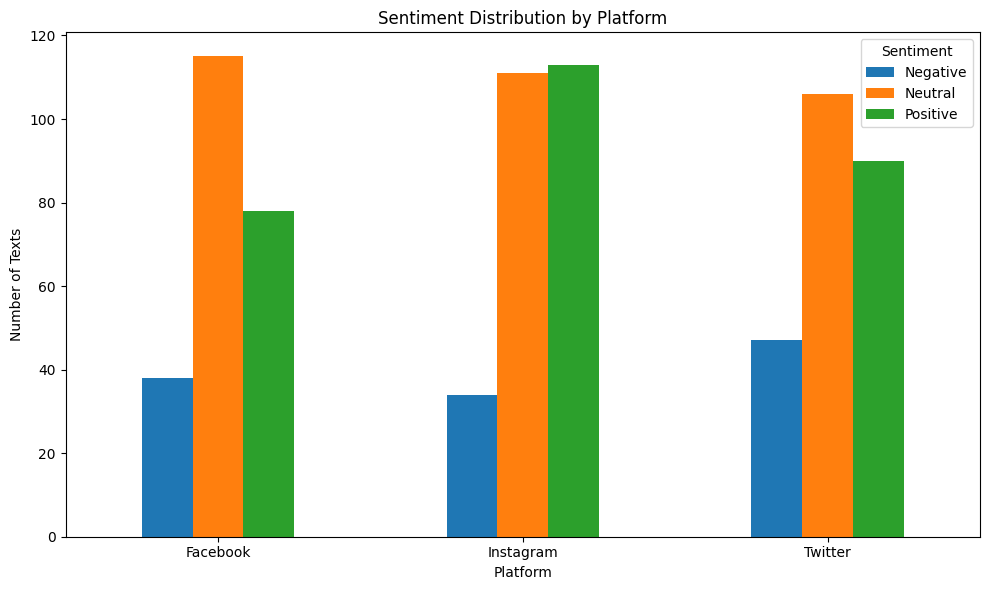

In [ ]:
platform_sentiment.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Sentiment Distribution by Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Texts')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("sentiment_analysis_results.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!
